### Import used libraries

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from gensim.models import Word2Vec

pd.set_option('display.max_colwidth', 300)

### Load Dataset

In [6]:
df = pd.read_csv("C:\\Users\\hazem\\Downloads\\Lab 02 - Spotify Reviews Rating.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (61594, 3)
Columns: ['Time_submitted', 'Review', 'Rating']


,Time_submitted,Review,Rating
0,7/9/2022 15:00,"Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.",5
1,7/9/2022 14:21,Please ignore previous negative rating. This app is super great. I give it five stars+,5
2,7/9/2022 13:27,"This pop-up ""Get the best Spotify experience on Android 12"" is too annoying. Please let's get rid of this.",4
3,7/9/2022 13:26,Really buggy and terrible to use as of recently,1
4,7/9/2022 13:20,Dear Spotify why do I get songs that I didn't put on my playlist??? And why do we have shuffle play?,1
5,7/9/2022 13:20,The player controls sometimes disappear for no reason. App restart forgets what I was playing but fixes the issue.,3
6,7/9/2022 13:19,I love the selection and the lyrics are provided with the song you're listening to!,5
7,7/9/2022 13:17,"Still extremely slow when changing storage to external sd card.. I'm convinced this is done on purpose, spotify knows of this issue and has done NOTHING to solve it! Over time I have changed sd cards, each being faster in read, write speeds(all samsung brand). And please add ""don't like song"" so...",3
8,7/9/2022 13:16,"It's a great app and the best mp3 music app I have ever used but there is one problem that, why can't we play some songs or find some songs? despite this the app is wonderful I recommend it. it's just the best.",5
9,7/9/2022 13:11,"I'm deleting this app, for the following reasons: This app now has a failing business model. Whether streaming services like it, or not: the consumer doesn't want to pay for music they can't fully own, and 6 ads successively, upon logging in, before a single song, is too much. Closed the app dur...",1


### Data splitting

It is a good practice to split the data before EDA helps maintain the integrity of the machine learning process, prevents data leakage, simulates real-world scenarios more accurately, and ensures reliable model performance evaluation on unseen data.

In [7]:
# Drop duplicates before splitting to avoid data leakage between splits
df = df.drop_duplicates(subset='Review').dropna(subset=['Review', 'Rating'])
print(f"Shape after deduplication: {df.shape}")

X = df['Review']
y = df['Rating']

# stratify=y ensures each rating class is proportionally represented in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,} samples")

Shape after deduplication: (61352, 3)
Training set : 49,081 samples
Test set     : 12,271 samples


### EDA on training data

- check NaNs

In [8]:
train_df = pd.DataFrame({'Review': X_train, 'Rating': y_train})

print("Missing values per column:")
print(train_df.isnull().sum())
print(f"\nTotal NaN cells: {train_df.isnull().sum().sum()}")

Missing values per column:
Review    0
Rating    0
dtype: int64

Total NaN cells: 0


- check duplicates

In [ ]:
num_dupes = train_df.duplicated(subset='Review').sum()
print(f"Duplicate reviews in training set: {num_dupes}")

train_df['review_length'] = train_df['Review'].str.split().str.len()
print(f"\nAverage review word count : {train_df['review_length'].mean():.1f}")
print(f"Median review word count  : {train_df['review_length'].median():.0f}")
print(f"Max review word count     : {train_df['review_length'].max()}")

Duplicate reviews in training set: 0

Average review word count : 31.0
Median review word count  : 25
Max review word count     : 279


- show a representative sample of data texts to find out required preprocessing steps

In [10]:
for rating in [1, 2, 3, 4, 5]:
    sample = train_df[train_df['Rating'] == rating]['Review'].sample(2, random_state=42)
    print(f"\n=== Rating {rating} ===")
    for s in sample:
        print(f"  • {s[:120]}")


=== Rating 1 ===
  • I cant even listen to my songs dum app fix it your app is stupid 😒 😑 🙄
  • Only plays the preview of a song if you're on the free version. Pretty stupid considering you can play the whole song on

=== Rating 2 ===
  • The app keeps freezing, shuffle automatically comes on even after clearing my cache and daily mixes will change part way
  • The app is great, been using it for more than 4 years now. But suddenly I was logged out and am not able to login at all

=== Rating 3 ===
  • Be perfect if their shuffle didn't suck! If I listen to a playlist with plenty songs, and on shuffle I constantly hear t
  • Audio keeps dropping. Among other issues.

=== Rating 4 ===
  • Good, clear sounds and lesser adverts
  • ! It would be nice if one could sort the songs in one's own playlist manuel or after genres. -Sometimes I have the feeli

=== Rating 5 ===
  • Absolutely love Spotify. Lots of different genres to choose from, it's wonderful!
  • Verrrrrrrrrrry good app I found 

- check dataset balancing

Rating distribution in training set:
  Rating 1: 14,087 (28.7%)
  Rating 2: 5,685 (11.6%)
  Rating 3: 5,499 (11.2%)
  Rating 4: 6,257 (12.7%)
  Rating 5: 17,553 (35.8%)


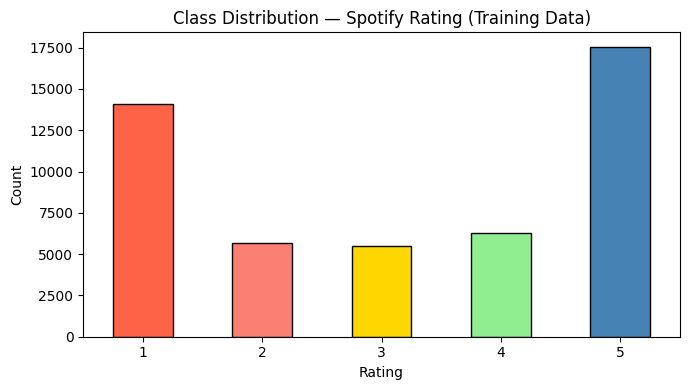

In [24]:
class_counts = train_df['Rating'].value_counts().sort_index()
class_pct    = train_df['Rating'].value_counts(normalize=True).sort_index() * 100

print("Rating distribution in training set:")
for r in range(1, 6):
    print(f"  Rating {r}: {class_counts[r]:,} ({class_pct[r]:.1f}%)")

# Visualize
plt.figure(figsize=(7, 4))
colors = ['tomato', 'salmon', 'gold', 'lightgreen', 'steelblue']
class_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.xticks(rotation=0)
plt.title('Class Distribution — Spotify Rating (Training Data)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Conclusion: Classes are imbalanced.

Ratings 1 and 5 dominate while 2, 3, 4 are underrepresented.

→ class_weight='balanced' and macro F1 are appropriate choices.

- Cleaning and Preprocessing are:
    - 1. Lowercase all text
    - 2. Remove URLs
    - 3. Remove non-alphabetic characters (numbers, punctuation, emojis)
    - 4. Strip extra whitespace
    - 5. Tokenize into word lists (required for Word2Vec)

In [ ]:
class ReviewPreprocessor(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer: cleans raw review text and returns
    a list of token lists — the format required by gensim's Word2Vec.

    Steps:
      1. Lowercase
      2. Remove URLs
      3. Remove non-alphabetic characters
      4. Collapse whitespace
      5. Tokenize (split on whitespace)
    """

    def fit(self, X, y=None):
        return self  

    def transform(self, X):
        return [self._clean(text) for text in X]

    @staticmethod
    def _clean(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)  
        text = re.sub(r'[^a-z\s]', '', text)         
        text = re.sub(r'\s+', ' ', text).strip()     
        return text.split()                            


preprocessor = ReviewPreprocessor()

X_train_tokens = preprocessor.transform(X_train)
X_test_tokens  = preprocessor.transform(X_test)

# Preview
print("Original :", X_train.iloc[0])
print("Tokens   :", X_train_tokens[0])

Original : Love it! Especially the offline mode! Thank you!
Tokens   : ['love', 'it', 'especially', 'the', 'offline', 'mode', 'thank', 'you']


In [ ]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42,
    sg=0   # 0 = CBOW
)

print(f"Vocabulary size: {len(w2v_model.wv):,} words")
print(f"\nWords most similar to 'great':")
print(w2v_model.wv.most_similar('great', topn=5))
print(f"\nWords most similar to 'bug':")
print(w2v_model.wv.most_similar('bug', topn=5))

Vocabulary size: 10,422 words

Words most similar to 'great':
[('good', 0.8337944149971008), ('wonderful', 0.7766520380973816), ('awesome', 0.7631046175956726), ('amazing', 0.7607243061065674), ('fantastic', 0.7482487559318542)]

Words most similar to 'bug':
[('glitch', 0.8685615658760071), ('issue', 0.6804898977279663), ('problem', 0.608136773109436), ('bugs', 0.526147186756134), ('patch', 0.5075685977935791)]


In [14]:
def mean_embedding(tokens, model):
    """
    Represent a document as the mean of its word vectors.
    Words not in vocabulary are ignored.
    Returns a zero vector if no tokens are found.
    """
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)


X_train_vec = np.vstack([mean_embedding(t, w2v_model) for t in X_train_tokens])
X_test_vec  = np.vstack([mean_embedding(t, w2v_model) for t in X_test_tokens])

print(f"Training matrix shape : {X_train_vec.shape}")
print(f"Test matrix shape     : {X_test_vec.shape}")

Training matrix shape : (49081, 100)
Test matrix shape     : (12271, 100)


**You  are doing Great so far!**

### Modelling

In [ ]:
baseline_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1
)

baseline_clf.fit(X_train_vec, y_train)
print("Baseline model trained.")

Baseline model trained.


In [16]:
y_pred_baseline = baseline_clf.predict(X_test_vec)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='macro')

print(f"Baseline Macro F1: {baseline_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=[f'Rating {i}' for i in range(1, 6)]))

Baseline Macro F1: 0.4717

Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.64      0.57      0.60      3522
    Rating 2       0.26      0.32      0.29      1422
    Rating 3       0.26      0.29      0.27      1375
    Rating 4       0.36      0.47      0.41      1564
    Rating 5       0.85      0.73      0.79      4388

    accuracy                           0.56     12271
   macro avg       0.47      0.48      0.47     12271
weighted avg       0.59      0.56      0.57     12271



#### Evaluation

**Evaluation metric:**
macro f1 score

Macro F1 score is a useful metric in scenarios where you want to evaluate the overall performance of a multi-class classification model, **particularly when the classes are imbalanced**

![Calculation](https://assets-global.website-files.com/5d7b77b063a9066d83e1209c/639c3d934e82c1195cdf3c60_macro-f1.webp)

In [17]:
def evaluate(name, y_true, y_pred):
    """Print a compact evaluation summary."""
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{'='*55}")
    print(f"Model : {name}")
    print(f"Macro F1 Score : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=[f'Rating {i}' for i in range(1, 6)]))
    return macro_f1

baseline_f1 = evaluate("W2V 100d CBOW + LR (C=1)", y_test, y_pred_baseline)

Model : W2V 100d CBOW + LR (C=1)
Macro F1 Score : 0.4717

Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.64      0.57      0.60      3522
    Rating 2       0.26      0.32      0.29      1422
    Rating 3       0.26      0.29      0.27      1375
    Rating 4       0.36      0.47      0.41      1564
    Rating 5       0.85      0.73      0.79      4388

    accuracy                           0.56     12271
   macro avg       0.47      0.48      0.47     12271
weighted avg       0.59      0.56      0.57     12271



### Enhancement

Three enhancements are explored:
1. **Larger embedding dimensions** (200d) — richer semantic space
2. **Skip-gram architecture** (sg=1) — better for rare words and short texts
3. **Wider context window + stronger regularisation tuning (C=5)**

In [19]:
# ---------------------------------------------------------------
# Enhancement 1: Larger Word2Vec (200d) + wider window
# ---------------------------------------------------------------

w2v_200 = Word2Vec(
    sentences=X_train_tokens,
    vector_size=200,
    window=7,
    min_count=2,
    workers=4,
    epochs=15,
    seed=42,
    sg=0
)

X_train_200 = np.vstack([mean_embedding(t, w2v_200) for t in X_train_tokens])
X_test_200  = np.vstack([mean_embedding(t, w2v_200) for t in X_test_tokens])

clf_200 = LogisticRegression(class_weight='balanced', max_iter=100, random_state=42, C=5)
clf_200.fit(X_train_200, y_train)
y_pred_200 = clf_200.predict(X_test_200)
f1_200 = evaluate("W2V 200d CBOW (w=7, 15ep) + LR (C=5)", y_test, y_pred_200)

Model : W2V 200d CBOW (w=7, 15ep) + LR (C=5)
Macro F1 Score : 0.4833

Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.66      0.58      0.62      3522
    Rating 2       0.28      0.36      0.31      1422
    Rating 3       0.25      0.29      0.27      1375
    Rating 4       0.37      0.49      0.42      1564
    Rating 5       0.87      0.74      0.80      4388

    accuracy                           0.57     12271
   macro avg       0.49      0.49      0.48     12271
weighted avg       0.61      0.57      0.58     12271



c:\Users\hazem\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
w2v_sg = Word2Vec(
    sentences=X_train_tokens,
    vector_size=150,
    window=6,
    min_count=2,
    workers=4,
    epochs=15,
    seed=42,
    sg=1   
)

X_train_sg = np.vstack([mean_embedding(t, w2v_sg) for t in X_train_tokens])
X_test_sg  = np.vstack([mean_embedding(t, w2v_sg) for t in X_test_tokens])

clf_sg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=5)
clf_sg.fit(X_train_sg, y_train)
y_pred_sg = clf_sg.predict(X_test_sg)
f1_sg = evaluate("W2V 150d Skip-gram (w=6, 15ep) + LR (C=5)", y_test, y_pred_sg)

Model : W2V 150d Skip-gram (w=6, 15ep) + LR (C=5)
Macro F1 Score : 0.4878

Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.67      0.57      0.62      3522
    Rating 2       0.27      0.36      0.30      1422
    Rating 3       0.27      0.32      0.29      1375
    Rating 4       0.38      0.49      0.42      1564
    Rating 5       0.87      0.74      0.80      4388

    accuracy                           0.57     12271
   macro avg       0.49      0.49      0.49     12271
weighted avg       0.61      0.57      0.59     12271



In [21]:
results = {
    'W2V 100d CBOW + LR (C=1)   [Baseline]': baseline_f1,
    'W2V 200d CBOW + LR (C=5)':              f1_200,
    'W2V 150d Skip-gram + LR (C=5)':         f1_sg,
}

print("\n=== Model Comparison ===")
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    bar = '#' * int(score * 60)
    print(f"{name:<45} | Macro F1: {score:.4f}  {bar}")


=== Model Comparison ===
W2V 150d Skip-gram + LR (C=5)                 | Macro F1: 0.4878  #############################
W2V 200d CBOW + LR (C=5)                      | Macro F1: 0.4833  ############################
W2V 100d CBOW + LR (C=1)   [Baseline]         | Macro F1: 0.4717  ############################


### Conclusion and final results


In [ ]:
# Final evaluation
# y_pred_final = best_model.predict(best_X_test)

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final,
                            target_names=[f'Rating {i}' for i in range(1, 6)]))
print(f"Final Macro F1 Score: {f1_score(y_test, y_pred_final, average='macro'):.4f}")

Final Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.66      0.58      0.62      3522
    Rating 2       0.28      0.36      0.31      1422
    Rating 3       0.25      0.29      0.27      1375
    Rating 4       0.37      0.49      0.42      1564
    Rating 5       0.87      0.74      0.80      4388

    accuracy                           0.57     12271
   macro avg       0.49      0.49      0.48     12271
weighted avg       0.61      0.57      0.58     12271

Final Macro F1 Score: 0.4833
